In [49]:
import os
os.chdir('/Users/madsbirch/Documents/4_semester/BAL/bayesian-active-learning')
print("Current working directory: {0}".format(os.getcwd()))

# OPTIONAL: Load the "autoreload" extension so that code can change
%load_ext autoreload
%autoreload 2

Current working directory: /Users/madsbirch/Documents/4_semester/BAL/bayesian-active-learning
The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [50]:
import time 
import random
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
from sklearn.datasets import make_moons, make_circles, make_classification
from matplotlib.colors import ListedColormap
from mpl_toolkits.axes_grid1 import make_axes_locatable
from sklearn.model_selection import train_test_split
from toma import toma
import math
from dataclasses import dataclass
from typing import List

import pickle

import torch
import torchvision
import torchvision.transforms as transforms

import torch.nn as nn
import torch.optim as optim
import torch.nn.functional as F
from torch.utils.data import DataLoader, random_split, SubsetRandomSampler
from torch.utils.data import DataLoader, Subset


from src.models.model import MLP
from src.data.data import get_dataloaders, TwoMoons
from src.models.train_model import train, test

torch.manual_seed(0)
np.random.seed(1)
random.seed(0)

# Set device
device = "mps" if torch.backends.mps.is_available() else "cpu"
print(f"Using device: {device}")

Using device: mps


In [69]:
from src.models.model import PaperCNN
from src.data.data import ActiveLearningDataset
from torchvision.datasets import MNIST
from typing import List
from src.features.acquistion_functions import query_the_oracle
import torch.utils.data as data

from src.data.data import MNIST_CUSTOM

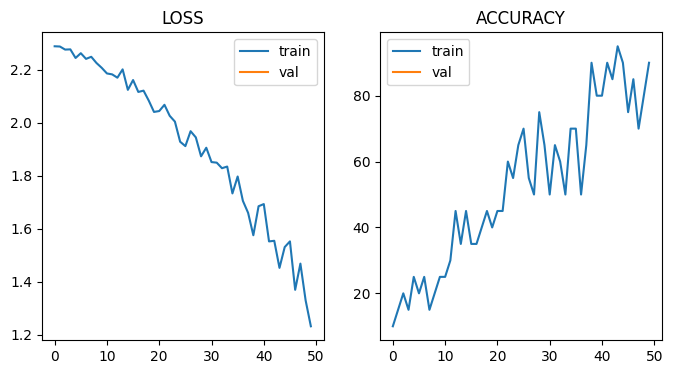

  0%|          | 0/20 [00:00<?, ?it/s]

70


Query [0/20]:   5%|▌         | 1/20 [00:03<01:06,  3.48s/it, test_acc=69.8]

120


Query [1/20]:  10%|█         | 2/20 [00:07<01:04,  3.58s/it, test_acc=77.2]

170


Query [2/20]:  15%|█▌        | 3/20 [00:11<01:03,  3.76s/it, test_acc=82.5]

220


Query [3/20]:  20%|██        | 4/20 [00:16<01:07,  4.22s/it, test_acc=85]  


IndexError: index 59854 is out of bounds for axis 0 with size 59780

In [81]:
from src.models.model import PaperCNN
from src.data.data import ActiveLearningDataset
from torchvision.datasets import MNIST
from typing import List
from src.features.acquistion_functions import query_the_oracle

TEST_ACC = []

# AL parameters
num_queries = 20
query_size = 50
T = 30

# get an active learning dataset
mnist_train = MNIST_CUSTOM(root='./data/raw', train=True, transform=transforms.ToTensor())
mnist_test = MNIST_CUSTOM(root='./data/raw', train=False, transform=transforms.ToTensor())
testloader = DataLoader(mnist_test, batch_size=512, shuffle=False, num_workers=0)

al_dataset = ActiveLearningDataset(mnist_train)

# call to get balanced initial pool
al_dataset.get_initial_balanced_trainset(n_per_class=2)

# define model
model = PaperCNN().to(device)
optimizer = optim.Adam(model.parameters(), lr = 1e-4)
trainloader = DataLoader(al_dataset.training_dataset, batch_size=256, shuffle=False, num_workers=0)

# train on initial pool 
model, optimizer = train(model, trainloader, optimizer, device, num_epochs=50, val = False, plot = True, printout = False)

TEST_ACC.append(test(model, testloader, device, display=False))

# start querying from the unlabeled pool
loop = tqdm(range(num_queries))
for query in loop:
    
    # query data points from unlabeled pool
    query_batch = query_the_oracle(device,
                                      model,
                                      al_dataset.pool_dataset,
                                      T = T,
                                      query_size=query_size,
                                      query_strategy= 'random',
                                      bald_method='MC_drop'
                                  )
    
    # update labeled pool with queried data points
    #print(f'Samples: {query_batch.indices} \n with scores: {query_batch.scores}')
    al_dataset.acquire_samples(query_batch.indices)
    print(len(al_dataset.training_dataset))
    
    # train on labeled pool subset
    labeled_loader = DataLoader(al_dataset.training_dataset, batch_size=256, num_workers=0,shuffle = False)
    model, optimizer = train(model, labeled_loader, optimizer, device, num_epochs=50, val = False, plot = False, printout = False)
    acc = test(model, testloader, device, display = False)
    
    # test model
    test_acc = test(model, testloader, device, display=False)
    TEST_ACC.append(test_acc)
    
    # loop info
    loop.set_description(f"Query [{query}/{num_queries}]")
    loop.set_postfix(test_acc=test_acc)
    
    

In [3]:
import numpy as np


def get_mixture_prob_dist(p1, p2, m):
    return (1.0 - m) * np.asarray(p1) + m * np.asarray(p2)

K = 20

p1 = [0.7, 0.1, 0.1, 0.1]
p2 = [0.3, 0.3, 0.2, 0.2]
y1_ws = [get_mixture_prob_dist(p1, p2, m) for m in np.linspace(0, 1, K)]

p1 = [0.1, 0.7, 0.1, 0.1]
p2 = [0.2, 0.3, 0.3, 0.2]
y2_ws = [get_mixture_prob_dist(p1, p2, m) for m in np.linspace(0, 1, K)]

p1 = [0.1, 0.1, 0.7, 0.1]
p2 = [0.2, 0.2, 0.3, 0.3]
y3_ws = [get_mixture_prob_dist(p1, p2, m) for m in np.linspace(0, 1, K)]

p1 = [0.1, 0.1, 0.1, 0.7]
p2 = [0.3, 0.2, 0.2, 0.3]
y4_ws = [get_mixture_prob_dist(p1, p2, m) for m in np.linspace(0, 1, K)]


def nested_to_tensor(l):
    return torch.stack(list(map(torch.as_tensor, l)))


ys_ws = nested_to_tensor([y1_ws, y2_ws, y3_ws, y4_ws])

/var/folders/dd/s080ztxj4q50zd2xnnx6t0t40000gn/T/ipykernel_7363/2584744409.py:27: UserWarning: Creating a tensor from a list of numpy.ndarrays is extremely slow. Please consider converting the list to a single numpy.ndarray with numpy.array() before converting to a tensor. (Triggered internally at /Users/runner/work/pytorch/pytorch/pytorch/torch/csrc/utils/tensor_new.cpp:233.)
  return torch.stack(list(map(torch.as_tensor, l)))


In [16]:
ys_ws.shape

torch.Size([4, 20, 4])

In [5]:
# hide

p = [0.25, 0.25, 0.25, 0.25]
yu_ws = [p for m in range(K)]
yus_ws = nested_to_tensor([yu_ws] * 4)

In [6]:
def compute_conditional_entropy(probs_N_K_C: torch.Tensor) -> torch.Tensor:
    N, K, C = probs_N_K_C.shape

    entropies_N = torch.empty(N, dtype=torch.double)

    pbar = tqdm(total=N, desc="Conditional Entropy", leave=False)

    @toma.execute.chunked(probs_N_K_C, 1024)
    def compute(probs_n_K_C, start: int, end: int):
        nats_n_K_C = probs_n_K_C * torch.log(probs_n_K_C)
        nats_n_K_C[probs_n_K_C == 0] = 0.0

        entropies_N[start:end].copy_(-torch.sum(nats_n_K_C, dim=(1, 2)) / K)
        pbar.update(end - start)

    pbar.close()

    return entropies_N


def compute_entropy(probs_N_K_C: torch.Tensor) -> torch.Tensor:
    N, K, C = probs_N_K_C.shape

    entropies_N = torch.empty(N, dtype=torch.double)

    pbar = tqdm(total=N, desc="Entropy", leave=False)

    @toma.execute.chunked(probs_N_K_C, 1024)
    def compute(probs_n_K_C, start: int, end: int):
        mean_probs_n_C = probs_n_K_C.mean(dim=1)
        nats_n_C = mean_probs_n_C * torch.log(mean_probs_n_C)
        nats_n_C[mean_probs_n_C == 0] = 0.0

        entropies_N[start:end].copy_(-torch.sum(nats_n_C, dim=1))
        pbar.update(end - start)

    pbar.close()

    return entropies_N

In [7]:

# Make sure everything is computed correctly.

assert np.allclose(compute_conditional_entropy(yus_ws), [1.3863, 1.3863, 1.3863, 1.3863], atol=0.1)
assert np.allclose(compute_entropy(yus_ws), [1.3863, 1.3863, 1.3863, 1.3863], atol=0.1)

In [8]:
# exports


def compute_conditional_entropy(log_probs_N_K_C: torch.Tensor) -> torch.Tensor:
    N, K, C = log_probs_N_K_C.shape

    entropies_N = torch.empty(N, dtype=torch.double)

    pbar = tqdm(total=N, desc="Conditional Entropy", leave=False)

    @toma.execute.chunked(log_probs_N_K_C, 1024)
    def compute(log_probs_n_K_C, start: int, end: int):
        nats_n_K_C = log_probs_n_K_C * torch.exp(log_probs_n_K_C)

        entropies_N[start:end].copy_(-torch.sum(nats_n_K_C, dim=(1, 2)) / K)
        pbar.update(end - start)

    pbar.close()

    return entropies_N


def compute_entropy(log_probs_N_K_C: torch.Tensor) -> torch.Tensor:
    N, K, C = log_probs_N_K_C.shape

    entropies_N = torch.empty(N, dtype=torch.double)

    pbar = tqdm(total=N, desc="Entropy", leave=False)

    @toma.execute.chunked(log_probs_N_K_C, 1024)
    def compute(log_probs_n_K_C, start: int, end: int):
        mean_log_probs_n_C = torch.logsumexp(log_probs_n_K_C, dim=1) - math.log(K)
        nats_n_C = mean_log_probs_n_C * torch.exp(mean_log_probs_n_C)

        entropies_N[start:end].copy_(-torch.sum(nats_n_C, dim=1))
        pbar.update(end - start)

    pbar.close()

    return entropies_N

In [9]:
# hide

# Make sure everything is computed correctly.
assert np.allclose(compute_conditional_entropy(yus_ws.log()), [1.3863, 1.3863, 1.3863, 1.3863], atol=0.1)
assert np.allclose(compute_entropy(yus_ws.log()), [1.3863, 1.3863, 1.3863, 1.3863], atol=0.1)

In [10]:
conditional_entropies = compute_conditional_entropy(ys_ws.log())

print(conditional_entropies)

assert np.allclose(conditional_entropies, [1.2069, 1.2069, 1.2069, 1.2069], atol=0.01)

tensor([1.2069, 1.2069, 1.2069, 1.2069], dtype=torch.float64)


In [11]:
entropies = compute_entropy(ys_ws.log())

print(entropies)

assert np.allclose(entropies, [1.2376, 1.2376, 1.2376, 1.2376], atol=0.01)

tensor([1.2376, 1.2376, 1.2376, 1.2376], dtype=torch.float64)


In [12]:
# exports
import src.models.joint_entropy as joint_entropy

@dataclass
class CandidateBatch:
    scores: List[float]
    indices: List[int]


def get_batchbald_batch(
    log_probs_N_K_C: torch.Tensor, batch_size: int, num_samples: int, dtype=None, device=None
) -> CandidateBatch:
    N, K, C = log_probs_N_K_C.shape

    batch_size = min(batch_size, N)

    candidate_indices = []
    candidate_scores = []

    if batch_size == 0:
        return CandidateBatch(candidate_scores, candidate_indices)

    conditional_entropies_N = compute_conditional_entropy(log_probs_N_K_C)

    batch_joint_entropy = joint_entropy.DynamicJointEntropy(
        num_samples, batch_size - 1, K, C, dtype=dtype, device=device
    )

    # We always keep these on the CPU.
    scores_N = torch.empty(N, dtype=torch.double, pin_memory=torch.cuda.is_available())

    for i in tqdm(range(batch_size), desc="BatchBALD", leave=False):
        if i > 0:
            latest_index = candidate_indices[-1]
            batch_joint_entropy.add_variables(log_probs_N_K_C[latest_index : latest_index + 1])

        shared_conditinal_entropies = conditional_entropies_N[candidate_indices].sum()

        batch_joint_entropy.compute_batch(log_probs_N_K_C, output_entropies_B=scores_N)

        scores_N -= conditional_entropies_N + shared_conditinal_entropies
        scores_N[candidate_indices] = -float("inf")

        candidate_score, candidate_index = scores_N.max(dim=0)

        candidate_indices.append(candidate_index.item())
        candidate_scores.append(candidate_score.item())

    return CandidateBatch(candidate_scores, candidate_indices)

In [13]:
get_batchbald_batch(ys_ws.log().double(), 4, 1000, dtype=torch.double)

BatchBALD:   0%|          | 0/4 [00:00<?, ?it/s]          

ExactJointEntropy.compute_batch:   0%|          | 0/4 [00:00<?, ?it/s]

BatchBALD:  25%|██▌       | 1/4 [00:00<00:00,  5.94it/s]

ExactJointEntropy.compute_batch:   0%|          | 0/4 [00:00<?, ?it/s]

BatchBALD:  50%|█████     | 2/4 [00:00<00:00,  6.30it/s]

ExactJointEntropy.compute_batch:   0%|          | 0/4 [00:00<?, ?it/s]

BatchBALD:  75%|███████▌  | 3/4 [00:00<00:00,  6.38it/s]

ExactJointEntropy.compute_batch:   0%|          | 0/4 [00:00<?, ?it/s]

CandidateBatch(scores=[0.030715639666234695, 0.05961958627158248, 0.0869107051474467, 0.11275304532467789], indices=[0, 1, 2, 3])

In [14]:


def get_bald_batch(log_probs_N_K_C: torch.Tensor, batch_size: int, dtype=None, device=None) -> CandidateBatch:
    N, K, C = log_probs_N_K_C.shape

    batch_size = min(batch_size, N)

    candidate_indices = []
    candidate_scores = []

    scores_N = -compute_conditional_entropy(log_probs_N_K_C)
    scores_N += compute_entropy(log_probs_N_K_C)

    candiate_scores, candidate_indices = torch.topk(scores_N, batch_size)

    return CandidateBatch(candiate_scores.tolist(), candidate_indices.tolist())

In [15]:
get_bald_batch(ys_ws.log().double(), 4)

CandidateBatch(scores=[0.030715639666234917, 0.030715639666234917, 0.030715639666234917, 0.030715639666234695], indices=[0, 1, 2, 3])